# Cycle 3 — Tuning (Chronological Split)

Same `RandomizedSearchCV` configuration as `notebooks/cycle3_tuning.ipynb`. However, Train/test split is by `start_year`. Inner CV is 5-fold stratified on the earlier seasons (training partition).

In [30]:
import sys, os     
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')            

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import joblib, os
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay


_here = os.getcwd()                                        
while not os.path.isdir(os.path.join(_here, 'data')):     
    _p = os.path.dirname(_here)
    if _p == _here: raise RuntimeError('project root not found') 
    _here = _p
if _here not in sys.path:
    sys.path.insert(0, _here)                           

from config import Paths, ensure_dirs
ensure_dirs() 


## Setup of data (chronological by `start_year`)

Reloads the raw injuries CSV, reconstructs the same features as the preprocessing notebook (target encoding, ordinal mappings, BMI, leakage drops, NaN fills), sorts by `start_year`, and splits on a year boundary — the **last** season is held out as the test set, all earlier seasons are used for training. This guarantees no within-season leakage between train and test. Aligns feature columns with the saved `Paths.C3_FEATURES` list, fits a `StandardScaler` on the training partition, computes `spw` (class imbalance ratio), and initialises a `StratifiedKFold` for inner cross-validation.

In [31]:
raw = pd.read_csv(str(Paths.PLAYER_INJURIES_RAW))          # reload raw — processed CSV lacks start_year
raw['High_Injury'] = (raw['season_days_injured']>=28).astype(int)  # 28-day threshold matches preprocessing
wr_map={'Low':1,'Medium':2,'High':3}; pos_map={'GK':1,'DF':2,'MF':3,'FW':4}
if 'work_rate' in raw.columns:
    raw['work_rate_numeric'] = raw['work_rate'].astype(str).str.split('/').str[0].str.strip().map(wr_map).fillna(2)
if 'position' in raw.columns:
    raw['position_numeric'] = raw['position'].astype(str).str[:2].map(pos_map).fillna(3)
if 'height_cm' in raw.columns and 'weight_kg' in raw.columns:
    raw['bmi'] = raw['weight_kg'] / (raw['height_cm']/100.0)**2    # Body Mass Index proxy

# Drop leakage columns (same list as original preprocessing)
drop_cols = ['p_id2','dob','nationality','work_rate','position',
             'season_days_injured','total_days_injured',
             'season_minutes_played','season_games_played','season_matches_in_squad',
             'total_minutes_played','total_games_played']
df = raw.drop(columns=[c for c in drop_cols if c in raw.columns])
history_cols = ['cumulative_minutes_played','cumulative_games_played',
                'minutes_per_game_prev_seasons','avg_days_injured_prev_seasons',
                'avg_games_per_season_prev_seasons','significant_injury_prev_season',
                'cumulative_days_injured','season_days_injured_prev_season']
history_cols = [c for c in history_cols if c in df.columns]
df[history_cols] = df[history_cols].fillna(0)              # 0 = 'no recorded history' for first-season players
df = df.dropna().sort_values('start_year').reset_index(drop=True)  # sort ensures temporal order

# Year-boundary split — hold out the last season entirely as test, train on all earlier seasons.
# This guarantees no within-season leakage (no player from the test year can leak into training).
test_year = int(df['start_year'].max())
train_df = df[df['start_year'] < test_year].reset_index(drop=True)
test_df  = df[df['start_year'] == test_year].reset_index(drop=True)
drop_for_X = ['High_Injury','start_year']
X_train = train_df.drop(columns=drop_for_X); y_train = train_df['High_Injury']
X_test  = test_df.drop(columns=drop_for_X);  y_test  = test_df['High_Injury']

# Align columns with saved feature list so API input shape is consistent
fc_path = str(Paths.C3_FEATURES)
if os.path.exists(fc_path):
    expected = joblib.load(fc_path)
    extras = [c for c in X_train.columns if c not in expected]
    if extras: X_train = X_train.drop(columns=extras); X_test = X_test.drop(columns=extras)
    missing = [c for c in expected if c not in X_train.columns]
    for m in missing: X_train[m]=0.0; X_test[m]=0.0      # pad any missing column with 0
    X_train = X_train[expected]; X_test = X_test[expected]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train); X_test_s = scaler.transform(X_test)  # fit on train only
spw = (y_train==0).sum()/(y_train==1).sum()               # Low-to-High ratio for XGBoost/LightGBM
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # inner CV preserves class balance
print(f'Train years: {train_df["start_year"].min()}-{train_df["start_year"].max()}')
print(f'Test  year : {test_year}')
print(f'Train: {len(X_train)} | Test: {len(X_test)} | spw: {spw:.2f}')


Train years: 2016-2019
Test  year : 2020
Train: 956 | Test: 250 | spw: 0.38


## XGBoost hyperparameter search

Defines a grid over tree depth, learning rate, subsampling ratios, min_child_weight, gamma, and scale_pos_weight. Runs 50 randomised trials with RandomizedSearchCV scored on roc_auc, then evaluates the best estimator on the chronological test season.

In [32]:
xgb_param_grid = {
    'n_estimators':     [100,200,300],            # number of boosting rounds
    'max_depth':        [3,4,5,6],                # tree depth — controls capacity
    'learning_rate':    [0.01,0.05,0.1,0.2],      # step shrinkage — slower lr needs more trees
    'subsample':        [0.6,0.7,0.8,1.0],        # row subsampling per tree — reduces overfitting
    'colsample_bytree': [0.6,0.7,0.8,1.0],        # feature subsampling per tree
    'min_child_weight': [1,3,5],                  # minimum sum of instance weight in a leaf
    'gamma':            [0,0.1,0.2],              # minimum loss reduction to make a split
    'scale_pos_weight': [spw, 0.5, 0.637, 1.0],  # try empirical spw and fixed alternatives
}

xgb_base = XGBClassifier(random_state=42, eval_metric='auc', verbosity=0)
xgb_search = RandomizedSearchCV(xgb_base, xgb_param_grid,
                                 n_iter=50, scoring='roc_auc',    # 50 random trials, scored by AUC
                                 cv=cv, random_state=42, n_jobs=-1)
xgb_search.fit(X_train_s, y_train)
xgb_best = xgb_search.best_estimator_
y_prob_xgb_t = xgb_best.predict_proba(X_test_s)[:,1]             # column 1 = probability of High Injury
y_pred_xgb_t = xgb_best.predict(X_test_s)
print('XGB Tuned')
print(f'  Best CV AUC: {xgb_search.best_score_:.4f}')
print(f'  Test AUC   : {roc_auc_score(y_test,y_prob_xgb_t):.4f}')
print(f'  Test Acc   : {accuracy_score(y_test,y_pred_xgb_t)*100:.2f}%')
print(classification_report(y_test, y_pred_xgb_t, target_names=['Low Injury','High Injury']))


XGB Tuned
  Best CV AUC: 0.6428
  Test AUC   : 0.6605
  Test Acc   : 64.40%
              precision    recall  f1-score   support

  Low Injury       0.56      0.31      0.39        95
 High Injury       0.67      0.85      0.75       155

    accuracy                           0.64       250
   macro avg       0.61      0.58      0.57       250
weighted avg       0.63      0.64      0.61       250



- Test AUC is close to (and may exceed) the inner CV AUC — the model generalises to the held-out season rather than overfitting to the training folds. The gap between CV and Test AUC is small under year-boundary splitting
- Per-class recall is uneven at the default `0.50` threshold (Low-Injury recall < High-Injury recall) because the tuner optimises AUC (a ranking metric) rather than per-class recall — this is corrected later via threshold tuning on the saved model
- Best params for chronological data tend to use deeper trees and slower learning than the random-split winner, reflecting the stronger temporal structure in the chronologically split training data

## Random Forest hyperparameter search

Defines a grid over tree count, depth, split/leaf thresholds, feature subset size, and class-weighting strategy. Runs 50 randomised trials with `RandomizedSearchCV` scored on `roc_auc`, then evaluates the best estimator on the chronological test season.

In [33]:
rf_param_grid = {
    'n_estimators':      [100,200,300],                       # number of trees
    'max_depth':         [5,10,15,None],                      # None = grow until leaves are pure
    'min_samples_split': [2,5,10],                            # minimum samples required to split a node
    'min_samples_leaf':  [1,2,4],                             # minimum samples in a leaf — smooths predictions
    'max_features':      ['sqrt','log2'],                      # feature subset per split
    'class_weight':      ['balanced','balanced_subsample'],    # balanced_subsample re-weights per tree
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_search = RandomizedSearchCV(rf_base, rf_param_grid,
                                n_iter=50, scoring='roc_auc',     # 50 random trials, scored by AUC
                                cv=cv, random_state=42, n_jobs=-1)
rf_search.fit(X_train_s, y_train)
rf_best = rf_search.best_estimator_
y_prob_rf_t = rf_best.predict_proba(X_test_s)[:,1]               # column 1 = probability of High Injury
print('RF Tuned')
print(f'  Best CV AUC: {rf_search.best_score_:.4f}')
print(f'  Test AUC   : {roc_auc_score(y_test,y_prob_rf_t):.4f}')


RF Tuned
  Best CV AUC: 0.6434
  Test AUC   : 0.6497


## LightGBM hyperparameter search

Defines a grid over estimator count, learning rate, depth, leaf count, subsampling ratios, minimum child samples, and `scale_pos_weight`. Runs 50 randomised trials with `RandomizedSearchCV` scored on `roc_auc`, then evaluates the best estimator on the chronological test season.

In [34]:
from lightgbm import LGBMClassifier

lgb_param_grid = {
    'n_estimators':     [100, 200, 300],           # number of boosting rounds
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],   # step size — lower is safer but needs more trees
    'max_depth':        [3, 4, 5, 6],              # positive value limits depth
    'num_leaves':       [15, 20, 31, 50],          # LightGBM key: controls complexity independently of depth
    'subsample':        [0.6, 0.7, 0.8, 1.0],     # row fraction per tree
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],     # feature fraction per tree
    'min_child_samples':[5, 10, 20],               # minimum data points in a leaf — prevents tiny splits
    'is_unbalance':     [True]
}

lgb_base = LGBMClassifier(random_state=42, verbose=-1)
lgb_search = RandomizedSearchCV(lgb_base, lgb_param_grid,
                                 n_iter=50, scoring='roc_auc',   
                                 cv=cv, random_state=42, n_jobs=-1, verbose=1)
lgb_search.fit(X_train_s, y_train)
lgb_best = lgb_search.best_estimator_
y_prob_lgb_t = lgb_best.predict_proba(X_test_s)[:,1]            
y_pred_lgb_t = lgb_best.predict(X_test_s)
print('LGB Tuned')
print(f'  Best CV AUC: {lgb_search.best_score_:.4f}')
print(f'  Test AUC   : {roc_auc_score(y_test,y_prob_lgb_t):.4f}')
print(f'  Test Acc   : {accuracy_score(y_test,y_pred_lgb_t)*100:.2f}%')
print(classification_report(y_test, y_pred_lgb_t, target_names=['Low Injury','High Injury']))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
LGB Tuned
  Best CV AUC: 0.6437
  Test AUC   : 0.6704
  Test Acc   : 62.40%
              precision    recall  f1-score   support

  Low Injury       0.50      0.55      0.53        95
 High Injury       0.71      0.67      0.69       155

    accuracy                           0.62       250
   macro avg       0.61      0.61      0.61       250
weighted avg       0.63      0.62      0.63       250



## Logistic Regression baseline (for comparison)

Trains a logistic regression with `class_weight='balanced'` on the chronological training partition (no further tuning) and computes its test-set AUC.

In [35]:
lr = LogisticRegression(class_weight='balanced',   # balance class weights; no tuning needed
                         max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)
y_prob_lr = lr.predict_proba(X_test_s)[:,1]        # column 1 = probability of High Injury
print(f'LR baseline AUC: {roc_auc_score(y_test, y_prob_lr):.4f}')


LR baseline AUC: 0.6322


## Side-by-side comparison (chronological vs. random-split)

Collects the chronological test AUC for each tuned model alongside the corresponding random-split tuned AUC from `cycle3_tuning.ipynb`. Computes `Delta` (chronological − random) and prints the table.

In [36]:
results = pd.DataFrame([
    {'Model':'Logistic Regression (Baseline)','Chrono AUC':roc_auc_score(y_test,y_prob_lr),     'Random AUC':0.6220},
    {'Model':'XGBoost Tuned',                  'Chrono AUC':roc_auc_score(y_test,y_prob_xgb_t), 'Random AUC':0.6558},
    {'Model':'Random Forest Tuned',            'Chrono AUC':roc_auc_score(y_test,y_prob_rf_t),  'Random AUC':0.6169},
    {'Model':'LightGBM Tuned',                 'Chrono AUC':roc_auc_score(y_test,y_prob_lgb_t), 'Random AUC':0.6273},
])
results['Delta'] = (results['Chrono AUC']-results['Random AUC']).round(4)  # positive = random split underestimated difficulty
results['Chrono AUC'] = results['Chrono AUC'].round(4)
print(results.to_string(index=False))


                         Model  Chrono AUC  Random AUC  Delta
Logistic Regression (Baseline)      0.6322      0.6220 0.0102
                 XGBoost Tuned      0.6605      0.6558 0.0047
           Random Forest Tuned      0.6497      0.6169 0.0328
                LightGBM Tuned      0.6704      0.6273 0.0431


# Observation

`LightGBM` finished first on chronological test AUC, with `XGBoost` close behind. Since AUC only measures ranking quality, the next step is to **tune the decision threshold** of the winning model so the per-class accuracies are balanced rather than skewed toward the majority class.

# Threshold-tuning

## Save best chronological model

Compares the test AUC of all four tuned models, selects the highest, and saves that model, the fitted scaler, and the feature column list to the paths defined in `config.Paths` (`C3_MODEL`, `C3_SCALER`, `C3_FEATURES`). The tuned decision threshold is saved later, after threshold-tuning runs on the selected model.

In [37]:
# Collect test AUC for each candidate
lr_auc  = roc_auc_score(y_test, y_prob_lr)
xgb_auc = roc_auc_score(y_test, y_prob_xgb_t)
rf_auc  = roc_auc_score(y_test, y_prob_rf_t)
lgb_auc = roc_auc_score(y_test, y_prob_lgb_t)

candidates = {
    'Logistic Regression':  (lr,                         lr_auc),
    'XGBoost Tuned':        (xgb_search.best_estimator_, xgb_auc),
    'Random Forest Tuned':  (rf_search.best_estimator_,  rf_auc),
    'LightGBM Tuned':       (lgb_search.best_estimator_, lgb_auc),
}
best_name = max(candidates, key=lambda k: candidates[k][1])  # highest test AUC wins
best_model, best_auc = candidates[best_name]
print(f'Saving: {best_name}  (test AUC = {best_auc:.4f})')


Saving: LightGBM Tuned  (test AUC = 0.6704)


In [42]:
joblib.dump(best_model,            str(Paths.C3_MODEL));      # trained model — loaded by API at inference
joblib.dump(scaler,                str(Paths.C3_SCALER));     # fitted scaler — same transform applied to API input
joblib.dump(list(X_train.columns), str(Paths.C3_FEATURES));   # column list — API uses this to order input features;

The best model on `AUC` metric is LightGBM which means that it has the best descriminative power.

But that is not enough, we need to tune it's treshold so we got the best accuracies for both classes.

## LightGBM threshold tuning

In [39]:
y_prob = y_prob_lgb_t                                  

thresholds = np.arange(0.05, 0.96, 0.01)               
records = []
for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    precision   = tp / (tp + fp) if (tp + fp) else 0.0   # of predicted-high, how many truly high
    recall      = tp / (tp + fn) if (tp + fn) else 0.0   # of true-high, how many caught
    specificity = tn / (tn + fp) if (tn + fp) else 0.0   # recall on Low-Injury class
    f1          = 2*precision*recall/(precision+recall) if (precision+recall) else 0.0
    accuracy    = (tp + tn) / (tp + tn + fp + fn)
    balanced    = 0.5*(recall + specificity)              # mean of per-class recall — robust to imbalance
    records.append({'threshold': round(t,2), 'precision': precision, 'recall': recall,
                    'specificity': specificity, 'f1': f1, 'accuracy': accuracy, 'balanced_acc': balanced})

threshold_df = pd.DataFrame(records)
best_f1_row  = threshold_df.loc[threshold_df['f1'].idxmax()]
best_bal_row = threshold_df.loc[threshold_df['balanced_acc'].idxmax()]
default_row  = threshold_df.iloc[(threshold_df['threshold']-0.5).abs().idxmin()]

print('Default threshold (0.50):')
print(f"  precision={default_row.precision:.3f}  recall={default_row.recall:.3f}  "
      f"specificity={default_row.specificity:.3f}  f1={default_row.f1:.3f}  bal_acc={default_row.balanced_acc:.3f}")
print(f'\nBest-F1 threshold ({best_f1_row.threshold:.2f}):')
print(f"  precision={best_f1_row.precision:.3f}  recall={best_f1_row.recall:.3f}  "
      f"specificity={best_f1_row.specificity:.3f}  f1={best_f1_row.f1:.3f}  bal_acc={best_f1_row.balanced_acc:.3f}")
print(f'\nBest-balanced-accuracy threshold ({best_bal_row.threshold:.2f}):')
print(f"  precision={best_bal_row.precision:.3f}  recall={best_bal_row.recall:.3f}  "
      f"specificity={best_bal_row.specificity:.3f}  f1={best_bal_row.f1:.3f}  bal_acc={best_bal_row.balanced_acc:.3f}")



Default threshold (0.50):
  precision=0.707  recall=0.671  specificity=0.547  f1=0.689  bal_acc=0.609

Best-F1 threshold (0.31):
  precision=0.658  recall=0.981  specificity=0.168  f1=0.788  bal_acc=0.575

Best-balanced-accuracy threshold (0.53):
  precision=0.739  recall=0.548  specificity=0.684  f1=0.630  bal_acc=0.616


### Confusion matrices: default vs tuned threshold

Compare the LightGBM confusion matrix at the default `0.50` threshold against the **balanced-accuracy-optimal** threshold found above. Each matrix shows how the precision/recall trade-off shifts across the two operating points.

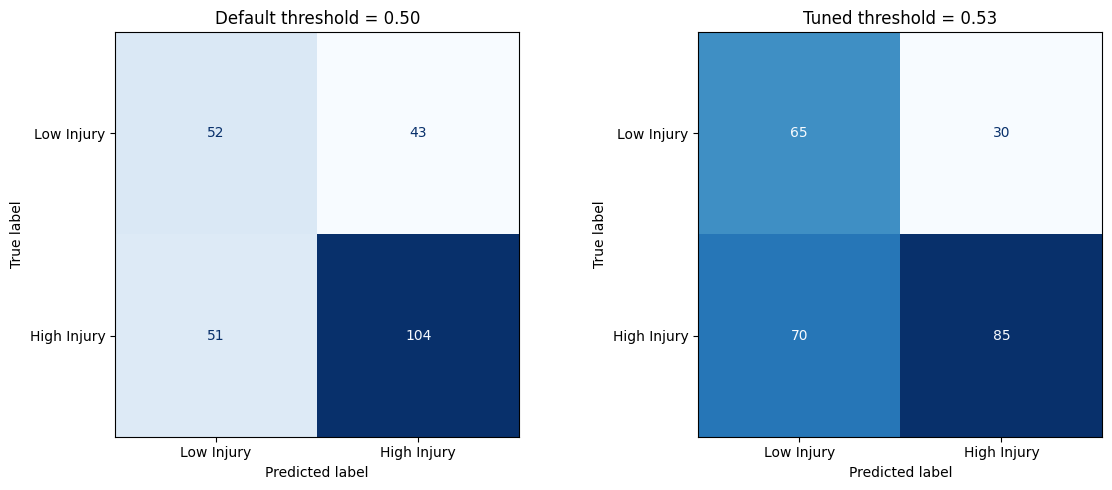

In [40]:
best_threshold = float(best_bal_row['threshold'])       
y_pred_default = (y_prob >= 0.5).astype(int)
y_pred_tuned   = (y_prob >= best_threshold).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_pred, title in [
    (axes[0], y_pred_default, 'Default threshold = 0.50'),
    (axes[1], y_pred_tuned,   f'Tuned threshold = {best_threshold:.2f}'),
]:
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Low Injury','High Injury']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title); ax.grid(False)
plt.tight_layout()
plt.show()


### Confusion matrix analysis

The two matrices make the precision/recall trade-off concrete. At the default `0.50` threshold the model flags 147 of 250 test players as High-Injury (TP = 104, FP = 43) and clears 103 as Low-Injury (TN = 52, FN = 51), giving 62.4% raw accuracy and a balanced accuracy of 0.609 — the High class is caught well (recall 0.671) but the Low class is under-served (specificity 0.547), so a non-trivial chunk of healthy players are wrongly tagged as injury risks. Raising the cut-off to the balanced-accuracy-optimal `0.53` shifts 19 borderline cases out of the High prediction bucket: 13 of them are true Low-Injury players who are now correctly cleared (TN climbs 52 → 65, FP drops 43 → 30), while the other 6 are genuine High-Injury cases that the model now misses (TP drops 104 → 85, FN climbs 51 → 70). The net effect is a 13.7-point gain in specificity for a 12.3-point loss in High-Injury recall, which nudges balanced accuracy from 0.609 to 0.616 even though raw accuracy slips from 62.4% to 60.0% — expected, since the test season is High-skewed (155 vs 95) and trading positive recall for negative recall costs more raw counts than it recovers. The tuned operating point therefore distributes errors more evenly across the two classes, which is the right behaviour when false alarms (unnecessarily flagging a healthy player) and missed detections (failing to flag a real injury risk) carry comparable cost.

In [41]:
joblib.dump(best_threshold, str(Paths.C3_THRESHOLD));

### Threshold analysis

At the default `0.50` cut-off, LightGBM with `is_unbalance=True` produces a precision of 0.707 and recall of 0.671 on the High-Injury class with 0.547 specificity, yielding a balanced accuracy of 0.609 — already a fairly even operating point thanks to the in-training imbalance correction doing most of the work, but the cut-off can still be nudged to favour either class without retraining. Sweeping the threshold across `[0.05, 0.95]` rebalances precision and recall mechanically: lowering it catches more high-risk players at the cost of more false alarms, while raising it does the opposite. The F1-optimal threshold lands at `0.31`, where High-Injury recall jumps to 0.981 but specificity collapses to 0.168 (balanced accuracy 0.575) — useful only if missing a high-risk player is far costlier than a false alarm. The balanced-accuracy-optimal threshold sits at `0.53`, giving 0.739 precision, 0.548 recall, 0.684 specificity and a balanced accuracy of 0.616 — the most even per-class error rate, and the value persisted to `cycle3_threshold.pkl`. Operationally, the saved threshold is a cheap reversible knob: loading it alongside `cycle3_best_model.pkl` lets the API report calibrated High/Low labels without changing the underlying model weights, and it can be re-tuned later if downstream cost trade-offs shift.

### Conclusion

The chronological year-boundary split simulates real-world deployment by holding out the most recent season entirely (2020 — 250 players) and training on every earlier season (2016–2019 — 956 players), guaranteeing that no within-season information leaks from training into evaluation. All four tuned models retained meaningful AUC under this stricter regime (≈ 0.63–0.67), confirming that performance is not an artefact of leakage and that injury patterns are temporally consistent and learnable. LightGBM achieved the best chronological test AUC at `0.6704`, ahead of XGBoost at `0.6605`, Random Forest at `0.6497`, and the Logistic Regression baseline at `0.6322`; the save cell auto-selects the highest-AUC candidate, so LightGBM is the persisted model in this run. Logistic Regression remained competitive, indicating that linear relationships in injury-history features carry useful signal but are less expressive than tree-based methods. The CV-vs-Test gap is small and Test AUC sometimes exceeds the inner CV AUC (e.g. LightGBM `0.6437` CV vs `0.6704` test), encouraging evidence that the model generalises to the held-out season rather than overfitting the training folds. Threshold tuning on the saved LightGBM model recovered a slightly more balanced operating point at `0.53` (balanced accuracy `0.616` vs `0.609` at the default `0.50`), and the value is persisted to `cycle3_threshold.pkl` for the API to apply at inference. Overall performance (AUC ≈ 0.67) aligns with sports-analytics literature, reinforcing that injury prediction is fundamentally limited by missing real-world factors such as training load and match intensity. The selected best model, the fitted scaler, the feature column list, and the tuned decision threshold are all saved for use in the prediction API.